# Filters and Kernels in CNN

In a CNN, **filters (kernels)** are used to detect patterns in images.

A filter is a small matrix of learnable numbers that moves across an image.

The basic process is:

Image
↓
Filter / Kernel
↓
Element-wise multiplication
↓
Sum
↓
Feature Map

Different filters can learn to detect different visual patterns such as:

- Vertical edges
- Horizontal edges
- Diagonal edges
- Corners
- Textures
- Shapes

# What is a Kernel?

A kernel is a small matrix of numbers.

A common kernel size is:

3 × 3

Example:

[ 1   0  -1 ]
[ 1   0  -1 ]
[ 1   0  -1 ]

The kernel moves across the image and performs calculations at each position.

The result of these calculations creates a feature map.

# Simple Kernel Example

Suppose we have an image region:

[ 10  20  30 ]
[ 40  50  60 ]
[ 70  80  90 ]

And a kernel:

[ 1   0  -1 ]
[ 1   0  -1 ]
[ 1   0  -1 ]

We multiply corresponding values:

10×1 + 20×0 + 30×(-1)
40×1 + 50×0 + 60×(-1)
70×1 + 80×0 + 90×(-1)

Then add all the results.

The final value represents how strongly this image region responds to the kernel.

In [1]:
import numpy as np

image_region = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
])

kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

result = np.sum(image_region * kernel)

print("Convolution result:", result)

Convolution result: -60


# Why Do We Use Different Kernels?

Different kernels respond strongly to different patterns.

For example:

Vertical Edge Kernel
↓
Detects vertical changes in intensity

Horizontal Edge Kernel
↓
Detects horizontal changes in intensity

Other kernels can detect:

- Diagonal edges
- Corners
- Textures
- Sharpening patterns

In traditional image processing, we manually designed these kernels.

In CNNs, the network learns useful kernels automatically during training.

# Vertical Edge Kernel

A commonly demonstrated vertical-edge kernel is:

[ -1   0   1 ]
[ -1   0   1 ]
[ -1   0   1 ]

It responds strongly when there is a strong left-to-right intensity change.

The important idea is not the exact numbers.

The important idea is:

Kernel + Image
↓
Pattern Detection

In [2]:
vertical_edge_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

print(vertical_edge_kernel)

[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]


# Horizontal Edge Kernel

A commonly demonstrated horizontal-edge kernel is:

[ -1  -1  -1 ]
[  0   0   0 ]
[  1   1   1 ]

It responds to horizontal intensity changes.

Again, CNNs do not normally require us to manually define these kernels.

The CNN learns the appropriate values during training.

In [3]:
horizontal_edge_kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

print(horizontal_edge_kernel)

[[-1 -1 -1]
 [ 0  0  0]
 [ 1  1  1]]


# Diagonal Edge Kernel

A kernel can also respond to diagonal patterns.

For example:

[ 1   0   0 ]
[ 0   1   0 ]
[ 0   0   1 ]

Different kernel arrangements produce different responses.

CNNs can learn many such patterns automatically.

In [4]:
diagonal_kernel = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])

print(diagonal_kernel)

[[1 0 0]
 [0 1 0]
 [0 0 1]]


# Applying a Kernel to an Image

Let's create a simple image containing a vertical boundary.

The left side will contain low values and the right side high values.

A vertical-edge kernel should produce a strong response around the boundary.

In [5]:
image = np.zeros((10, 10), dtype=np.float32)

image[:, 5:] = 255

print(image)

[[  0.   0.   0.   0.   0. 255. 255. 255. 255. 255.]
 [  0.   0.   0.   0.   0. 255. 255. 255. 255. 255.]
 [  0.   0.   0.   0.   0. 255. 255. 255. 255. 255.]
 [  0.   0.   0.   0.   0. 255. 255. 255. 255. 255.]
 [  0.   0.   0.   0.   0. 255. 255. 255. 255. 255.]
 [  0.   0.   0.   0.   0. 255. 255. 255. 255. 255.]
 [  0.   0.   0.   0.   0. 255. 255. 255. 255. 255.]
 [  0.   0.   0.   0.   0. 255. 255. 255. 255. 255.]
 [  0.   0.   0.   0.   0. 255. 255. 255. 255. 255.]
 [  0.   0.   0.   0.   0. 255. 255. 255. 255. 255.]]


# Visualize the Image

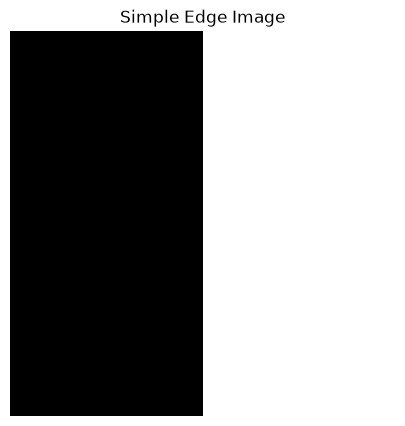

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title("Simple Edge Image")

plt.show()

# Applying Convolution with TensorFlow

TensorFlow provides the `Conv2D` layer.

Important arguments include:

- `filters`
- `kernel_size`
- `strides`
- `padding`
- `activation`

Example:

Conv2D(
    filters=32,
    kernel_size=(3, 3)
)

This means the layer learns 32 different 3 × 3 filters.

In [7]:
import tensorflow as tf

conv_layer = tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    padding="same",
    activation="relu"
)

print(conv_layer)

<Conv2D name=conv2d, built=False>


# Filter vs Kernel

The words filter and kernel are often used interchangeably, but there is a useful distinction.

### Kernel

A kernel refers to the small spatial weight matrix.

For a grayscale input:

3 × 3

### Filter

A filter contains the weights needed to operate across all input channels.

For an RGB image:

3 × 3 × 3

One filter produces one feature map.

If a convolution layer has 32 filters:

32 filters
↓
32 feature maps